In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
# Step 1: Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Step 2: Padding
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Step 3: Build Model
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.summary()

# Step 4: Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Step 5: Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 248ms/step - accuracy: 0.7959 - loss: 0.4329 - val_accuracy: 0.8574 - val_loss: 0.3360
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 250ms/step - accuracy: 0.8992 - loss: 0.2565 - val_accuracy: 0.8554 - val_loss: 0.3488
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 248ms/step - accuracy: 0.9322 - loss: 0.1811 - val_accuracy: 0.8376 - val_loss: 0.3955
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 247ms/step - accuracy: 0.9470 - loss: 0.1448 - val_accuracy: 0.8636 - val_loss: 0.4102
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 247ms/step - accuracy: 0.9648 - loss: 0.1007 - val_accuracy: 0.8560 - val_loss: 0.4122


In [6]:
# Step 6: Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8524 - loss: 0.4215
Test Accuracy: 0.8523600101470947


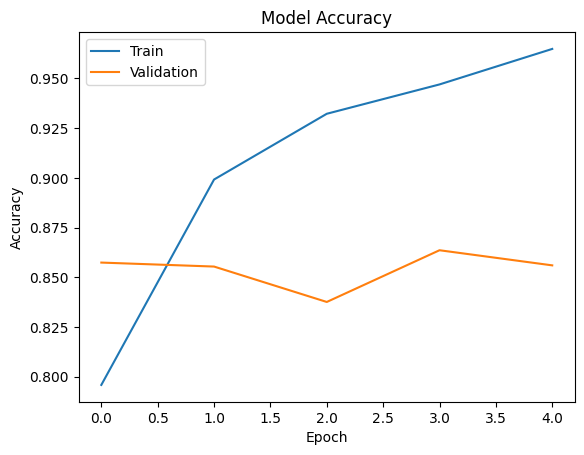

In [7]:
# Step 7: Plot Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()